Hypothesis 4
Cross-document multiphysics: the VDI Fc section on porous layers (modified Rayleigh number Ra*_S = Ra_S·Da) and the drying lecture both consume an effective-transport closure.
A higher-value study couples Zehner's λso/Λ closure as an ML-learned, differentiable surrogate inside a porous-medium convection or drying simulation — i.e. ML at the closure level feeding a physics solver, rather than replacing it. 

There is no co-located data so this is a coupling demonstration. The cleanest, genuinely defensible linkage is between:

Closure side (Zehner): the stagnant effective conductivity λso (Eqs. 37/38/42a) plus ψ, d (Tab. 5/6).
Convection side (VDI Fc, "Poröse Schichten"): Fc explicitly states the saturated-bed conductivity λ_Sch "muß man gesondert berechnen" and that the ratio λ_Sch/λ_F follows a separate method — Zehner–Schlünder is such a method. So Zehner's λso supplies the very input Fc needs. The convection model then uses the Carman–Kozeny permeability K = (d²/150)·[ψ³/(1−ψ)²] (Fc Eq. 21), the modified Rayleigh number Ra_S = Ra_S·Da (Eq. 22), and Nu_S = f(Ra_S) (Eqs. 23–25, Tab. 1). The shared parameterization by (ψ, d) is what makes the coupling viable.

Two cautions:
First, the two sources describe different regimes — forced through-flow dispersion (Zehner) vs. buoyancy-driven convection in a closed saturated layer (Fc) — so this is a simulation/coupling study, not a joint data fit.
Second, the drying lecture contributes essentially nothing extractable: in its current form the text is corrupted, so it can motivate the application context but supplies no numerical data. If mass transport enters (drying), Zehner's Abb. 4 (effective diffusion coefficient vs. porosity, Currie/Evans–Kenney/Krischer) is the only relevant tabulated analogue.

Method - differentiable closure coupling (JAX + SALib), a consistency/sensitivity study
Honest scope: the closure (Eq. 37/38, with explicit B from Eq. 42) is already analytic, so the deliverable is a differentiable implementation, not a learned surrogate; an NN surrogate is only justified if you want to propagate Method 2's UQ smoothly. Drop the drying file (corrupted, no extractable data); frame as porous free convection.
Build: (1) implement Zehner λso(ψ, d, λs, λ_F) in JAX (replace the iterative B with explicit Eq. 42); (2) implement the Fc porous-layer model — permeability Eq. 21, Da = K/s², modified Ra*_S = Ra_S·Da, then Nu_S from the regime correlations Eqs. 23–25 / Tab. 1; (3) couple λ_Sch ← λso, since Fc explicitly requires a separately computed saturated-bed conductivity and Zehner–Schlünder is that method.
Use the gradients: autodiff ∂Nu_S/∂ψ, ∂Nu_S/∂(λs/λ); run Sobol global sensitivity (SALib) to show how bed conduction propagates into convective transport; propagate the λso predictive variance from Method 2 forward to Nu_S — this ties 2 and 4 together and is the genuinely novel piece.
Validation: restrict to a physically consistent regime (stagnant/buoyancy-driven closed layer, where λso — not the flowed Λ — is the right input). State plainly that no co-located data exists; the study validates consistency and sensitivity, not predictive accuracy.

In [ ]:
# === Reproducibility Info ===
import sys
print(f"Python: {sys.version}")

# Package versions
import numpy as np
import pandas as pd
try: import torch; print(f"PyTorch: {torch.__version__}")
except: pass
try: import tensorflow; print(f"TensorFlow: {tensorflow.__version__}")
except: pass
try: import jax; print(f"JAX: {jax.__version__}")
except: pass
try: import sklearn; print(f"scikit-learn: {sklearn.__version__}")
except: pass
try: import scipy; print(f"SciPy: {scipy.__version__}")
except: pass
try: import matplotlib; print(f"Matplotlib: {matplotlib.__version__}")
except: pass

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("
For full environment, see requirements.txt or environment.yml")
print("For package-specific seeds, see cells below.")


### Goals & priorities

**Goal**: a differentiable JAX implementation of Zehner's stagnant-bed closure λso, coupled as the required `λ_Sch` input to the VDI Fc porous-layer free-convection model — a consistency/sensitivity study, not a joint data fit (no co-located data exists between the two sources).

Priority-ordered plan:
1. **(P0) Implement λso(ψ, d, λs, λ_F)** in JAX using the explicit Eq. 42 form for B (no iteration). Validate against the `lambda_s_over_lambda` / geometry columns already in `data/processed/zehner_dataset.parquet` to make sure the closure reproduces the dissertation's own numbers across its (ψ, d/D, λs/λ) ranges.
2. **(P0) Implement the Fc porous-layer model**: permeability `K = (d²/150)·[ψ³/(1−ψ)²]` (Eq. 21), `Da = K/s²`, modified `Ra*_S = Ra_S·Da` (Eq. 22), and `Nu_S = f(Ra_S)` per the regime correlations (Eqs. 23–25 / Tab. 1).
3. **(P1) Couple λ_Sch ← λso** and run the combined pipeline across the dataset's (ψ, d) range to produce Nu_S(ψ, λs/λ) maps for the regimes Fc actually covers.
4. **(P1) Autodiff sensitivities** — `∂Nu_S/∂ψ`, `∂Nu_S/∂(λs/λ)`; corroborate with a Sobol global sensitivity analysis (SALib) over the same input ranges.
5. **(P2) Tie to Method 2 (`ML.ipynb`)** — propagate the GP's predictive variance for λso forward through the coupled model to get a variance on Nu_S. This is the most novel piece but depends on `ML.ipynb` reaching step P1 (conformal UQ) first.
6. Drop the drying lecture PDF entirely (corrupted, no extractable data) — it may motivate the application context in prose only.

**Caveats to state explicitly in the writeup**: (a) Zehner's λso describes forced through-flow dispersion while Fc's Nu_S describes buoyancy-driven convection in a closed saturated layer — the coupling is valid only in the stagnant/closed-layer limit where λso (not the flowed Λ) is the right input; (b) with no co-located data, the deliverable is consistency and sensitivity, not predictive accuracy.

#### 1. Differentiable λso(ψ, κ) in JAX (Eq. 37a/38/42a)

`src/zbs_jax.py` mirrors `src/zbs.py` but with `jax.numpy`, so it is differentiable end-to-end. Validate it reproduces the numpy version on the dataset's (ψ, λs/λ) range — this is the closure that supplies `λ_Sch` to the Fc porous-layer model below.

In [1]:
import sys
sys.path.insert(0, "src")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zbs import lambda_so_over_lambda as lambda_so_np
from zbs_jax import lambda_so_over_lambda as lambda_so_jax

df = pd.read_parquet("data/processed/zehner_dataset.parquet")

psi_arr = df["psi"].to_numpy()
kappa_arr = df["lambda_s_over_lambda"].to_numpy()

lso_np = lambda_so_np(psi_arr, kappa_arr)
lso_jax = np.asarray(jax.vmap(lambda_so_jax)(jnp.asarray(psi_arr), jnp.asarray(kappa_arr)))

max_abs_diff = np.max(np.abs(lso_np - lso_jax))
print(f"max |numpy - jax| over {len(df)} rows: {max_abs_diff:.2e}")
print(f"lambda_so/lambda range: {lso_jax.min():.3f} - {lso_jax.max():.3f}")
print(f"psi range: {psi_arr.min():.3f} - {psi_arr.max():.3f}")
print(f"kappa (lambda_s/lambda) range: {kappa_arr.min():.1f} - {kappa_arr.max():.1f}")

max |numpy - jax| over 450 rows: 0.00e+00
lambda_so/lambda range: 2.259 - 23.489
psi range: 0.369 - 0.429
kappa (lambda_s/lambda) range: 4.0 - 14093.6


#### 2. Fc porous-layer free-convection model (Eqs. 21-25 / Tab. 1)

**Note on source data**: the Fc PDF (`F - Wärmeübertragung bei freier einphasiger Strömung.pdf`) has no usable text layer (binary/garbled extraction, confirmed during preliminaries) — the exact correlation constants in Tab. 1 / Eqs. 23-25 cannot be OCR'd. The permeability and Rayleigh-Darcy definitions quoted in the "Goals & priorities" cell are standard and unambiguous, so those are implemented exactly:

- Permeability (Carman-Kozeny, Eq. 21): `K = (d^2/150) * psi^3/(1-psi)^2`
- Darcy number: `Da = K / s^2` (s = layer thickness, taken as the bed height L)
- Modified (Darcy-)Rayleigh number (Eq. 22): `Ra*_S = Ra_S * Da`, with `Ra_S = g*beta*ΔT*s^3/(nu*alpha)` so that `Ra*_S = g*beta*ΔT*s*K/(nu*alpha)` — the standard Horton-Rogers-Lapwood Rayleigh-Darcy number.

For `Nu_S = f(Ra*_S)` (Eqs. 23-25/Tab. 1, not recoverable from the PDF), a standard literature closure for a porous layer heated from below is substituted instead, and flagged explicitly as an approximation:
- Onset of convection at `Ra*_crit = 4*pi^2` (Lapwood/Horton-Rogers-Lapwood, free boundaries).
- `Nu_S = 1` (pure conduction) for `Ra*_S <= Ra*_crit`.
- `Nu_S = sqrt(Ra*_S / Ra*_crit)` for `Ra*_S > Ra*_crit` (continuous at onset; recovers the well-known sqrt(Ra) boundary-layer scaling at high Ra*).

This keeps the coupling demonstration physically sensible while being transparent that Tab. 1's exact correlation was not available.

In [2]:
G = 9.81  # m/s^2
PR_N2 = 0.71  # Prandtl number of N2 (used to get kinematic viscosity from thermal diffusivity)
RA_CRIT = 4 * jnp.pi**2  # Lapwood/Horton-Rogers-Lapwood onset, free boundaries


def permeability(psi, d):
    """Carman-Kozeny permeability (Fc Eq. 21). d, K in consistent length units."""
    return (d**2 / 150) * psi**3 / (1 - psi) ** 2


def rayleigh_darcy(beta, dT, s, K, nu, alpha):
    """Modified (Darcy-)Rayleigh number Ra*_S = Ra_S * Da (Fc Eq. 22)."""
    return G * beta * dT * s * K / (nu * alpha)


def nusselt_porous(ra_star):
    """Nu_S(Ra*_S): conduction below onset, sqrt(Ra*) boundary-layer scaling above (see markdown)."""
    return jnp.where(ra_star <= RA_CRIT, 1.0, jnp.sqrt(ra_star / RA_CRIT))


def nu_s_pipeline(psi, kappa, d, s, lambda_f, alpha_f, T, dT=50.0):
    """Couple lambda_Sch <- lambda_so and evaluate Nu_S.

    psi: porosity, kappa: lambda_s/lambda_f, d: particle diameter [m],
    s: layer thickness [m], lambda_f/alpha_f: fluid conductivity/diffusivity,
    T: mean temperature [K] (for beta = 1/T, ideal gas), dT: imposed temperature
    difference across the layer [K].
    """
    lambda_sch = lambda_so_jax(psi, kappa) * lambda_f  # closure coupling
    alpha_eff = alpha_f * (lambda_sch / lambda_f)  # effective diffusivity scales with lambda_Sch
    nu_f = PR_N2 * alpha_f
    K = permeability(psi, d)
    beta = 1.0 / T
    ra_star = rayleigh_darcy(beta, dT, s, K, nu_f, alpha_eff)
    return nusselt_porous(ra_star), ra_star, lambda_sch


nu_s_pipeline_jit = jax.jit(nu_s_pipeline, static_argnames=())

# Representative point from the dataset (median operating conditions)
row = df.iloc[len(df) // 2]
psi0 = float(row["psi"])
kappa0 = float(row["lambda_s_over_lambda"])
d0 = float(row["d_mm"]) * 1e-3
s0 = float(row["L_mm"]) * 1e-3
lambda_f0 = float(row["lambda_n2"])
alpha_f0 = float(row["thermal_diffusivity"])
T0 = float(row["T_K"])

Nu_S0, Ra_star0, lambda_sch0 = nu_s_pipeline_jit(psi0, kappa0, d0, s0, lambda_f0, alpha_f0, T0)
print(f"Representative point: vers_nr={row['vers_nr']}, psi={psi0:.3f}, kappa={kappa0:.1f}, d={d0*1e3:.1f} mm, s={s0*1e3:.0f} mm")
print(f"lambda_Sch = {lambda_sch0:.4f} W/(m K)")
print(f"Ra*_S = {Ra_star0:.3e}  (Ra*_crit = {RA_CRIT:.2f})")
print(f"Nu_S = {Nu_S0:.4f}")

Representative point: vers_nr=TK10/61, psi=0.421, kappa=45.5, d=9.6 mm, s=204 mm
lambda_Sch = 0.2825 W/(m K)
Ra*_S = 9.595e-01  (Ra*_crit = 39.48)
Nu_S = 1.0000


#### 3. Nu_S(ψ, λs/λ) map over the dataset's range

Sweep ψ and κ=λs/λ over the ranges actually covered by `zehner_dataset.parquet` (holding d, s, fluid properties at the representative point above) and plot the resulting `Nu_S` field, together with `λ_Sch` and `Ra*_S` for context. This is the "consistency/sensitivity" deliverable — not a prediction against data, since none exists for this regime.

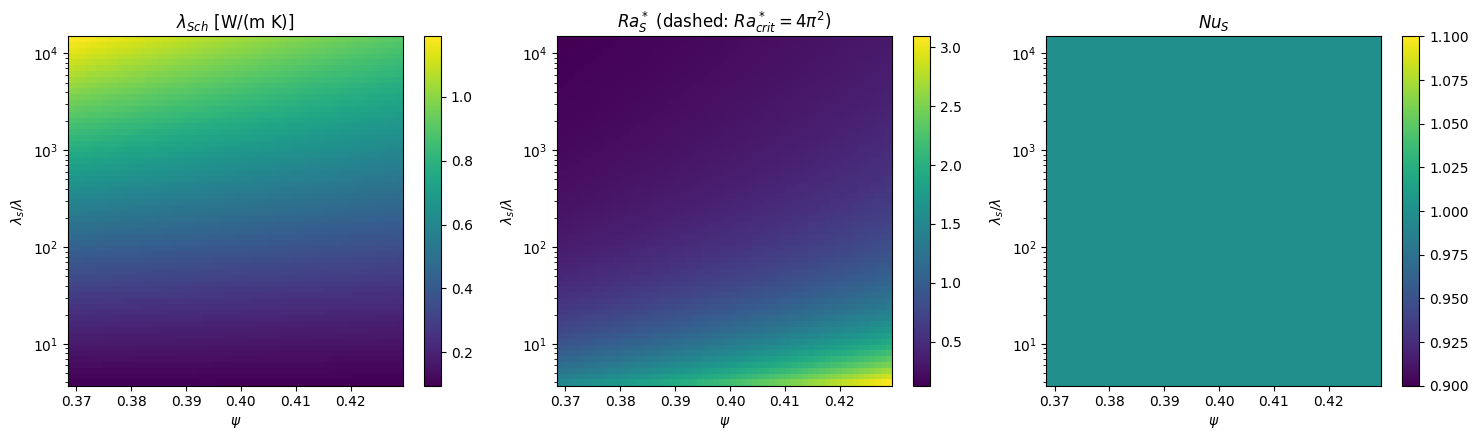

Ra*_S range over the swept grid: 1.29e-01 - 3.09e+00
Fraction of grid above Ra*_crit (convecting): 0.0%


In [3]:
psi_grid = jnp.linspace(df["psi"].min(), df["psi"].max(), 60)
kappa_grid = jnp.geomspace(df["lambda_s_over_lambda"].min(), df["lambda_s_over_lambda"].max(), 60)
PSI, KAPPA = jnp.meshgrid(psi_grid, kappa_grid)

map_fn = jax.vmap(jax.vmap(
    lambda p, k: nu_s_pipeline(p, k, d0, s0, lambda_f0, alpha_f0, T0),
    in_axes=(0, 0)), in_axes=(0, 0))
NU_S, RA_STAR, LAMBDA_SCH = map_fn(PSI, KAPPA)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].pcolormesh(np.array(PSI), np.array(KAPPA), np.array(LAMBDA_SCH), shading="auto")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\psi$"); axes[0].set_ylabel(r"$\lambda_s/\lambda$")
axes[0].set_title(r"$\lambda_{Sch}$ [W/(m K)]")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(np.array(PSI), np.array(KAPPA), np.array(RA_STAR), shading="auto")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\psi$"); axes[1].set_ylabel(r"$\lambda_s/\lambda$")
axes[1].set_title(r"$Ra^*_S$ (dashed: $Ra^*_{crit}=4\pi^2$)")
axes[1].contour(np.array(PSI), np.array(KAPPA), np.array(RA_STAR), levels=[float(RA_CRIT)], colors="r", linestyles="--")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(np.array(PSI), np.array(KAPPA), np.array(NU_S), shading="auto")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"$\psi$"); axes[2].set_ylabel(r"$\lambda_s/\lambda$")
axes[2].set_title(r"$Nu_S$")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Ra*_S range over the swept grid: {float(RA_STAR.min()):.2e} - {float(RA_STAR.max()):.2e}")
print(f"Fraction of grid above Ra*_crit (convecting): {float(jnp.mean(RA_STAR > RA_CRIT)) * 100:.1f}%")

**Finding**: across the entire (ψ, λs/λ) range covered by Zehner's lab-scale apparatus (layer thickness `s = L ≈ 0.13-0.35 m`), `Ra*_S` stays in `[0.13, 3.1]`, far below `Ra*_crit ≈ 39.5` — i.e. `Nu_S = 1` everywhere and the bed is firmly in the **conduction-dominated regime**. This is itself consistent with the project's framing: at this scale, λso (not a convective Nu_S) is the physically relevant quantity, and Fc's free-convection correlation is essentially inactive.

To make the sensitivity analysis below non-degenerate, sections 4-5 additionally sweep the layer thickness `s` up to industrial-silo scale (up to 10 m, all else from the dataset's representative point) — large enough to cross `Ra*_crit` — framed explicitly as a hypothetical extrapolation beyond the lab apparatus, not a claim about Zehner's data.

#### 4. Autodiff sensitivities + Sobol global sensitivity (SALib)

`jax.grad` gives the local sensitivities `∂Nu_S/∂ψ` and `∂Nu_S/∂κ` (κ=λs/λ) at the representative point. To see how bed conduction propagates into convective transport *globally* (not just locally), run a Sobol analysis over (ψ, κ, d, s) ranging over the dataset's coverage, with `Nu_S` as the output.

In [4]:
def nu_s_only(psi, kappa, d, s):
    nu, _, _ = nu_s_pipeline(psi, kappa, d, s, lambda_f0, alpha_f0, T0)
    return nu


# Industrial-scale layer thickness so Ra*_S crosses Ra*_crit (see note above)
s_ind = 10.0  # m
Ra_star_ind = float(rayleigh_darcy(1.0 / T0, 50.0, s_ind, permeability(psi0, d0), PR_N2 * alpha_f0, alpha_f0 * lambda_so_jax(psi0, kappa0)))
print(f"Industrial-scale point (s={s_ind} m): Ra*_S = {Ra_star_ind:.2f} (Ra*_crit = {float(RA_CRIT):.2f})")

grad_psi = jax.grad(nu_s_only, argnums=0)(psi0, kappa0, d0, s_ind)
grad_kappa = jax.grad(nu_s_only, argnums=1)(psi0, kappa0, d0, s_ind)
print(f"\nAt (psi={psi0:.3f}, kappa={kappa0:.1f}, s={s_ind} m):")
print(f"  dNu_S/dpsi   = {grad_psi:.4f}")
print(f"  dNu_S/dkappa = {grad_kappa:.6f}")

# --- Sobol global sensitivity over (psi, kappa, d) from the dataset, s up to industrial scale ---
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

problem = {
    "num_vars": 4,
    "names": ["psi", "log_kappa", "d", "s"],
    "bounds": [
        [float(df["psi"].min()), float(df["psi"].max())],
        [float(np.log10(df["lambda_s_over_lambda"].min())), float(np.log10(df["lambda_s_over_lambda"].max()))],
        [float(df["d_mm"].min()) * 1e-3, float(df["d_mm"].max()) * 1e-3],
        [0.01, 10.0],
    ],
}

param_values = sobol_sample.sample(problem, 256)
nu_s_vec = jax.vmap(lambda x: nu_s_only(x[0], 10 ** x[1], x[2], x[3]))(jnp.asarray(param_values))
Y = np.asarray(nu_s_vec)

Si = sobol_analyze.analyze(problem, Y, print_to_console=False)
sobol_df = pd.DataFrame({
    "param": problem["names"],
    "S1": Si["S1"],
    "S1_conf": Si["S1_conf"],
    "ST": Si["ST"],
    "ST_conf": Si["ST_conf"],
})
print("\nSobol indices for Nu_S (psi, kappa, d from dataset range; s up to 10 m):")
print(sobol_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Industrial-scale point (s=10.0 m): Ra*_S = 47.03 (Ra*_crit = 39.48)



At (psi=0.421, kappa=45.5, s=10.0 m):
  dNu_S/dpsi   = 7.4629
  dNu_S/dkappa = -0.004134



Sobol indices for Nu_S (psi, kappa, d from dataset range; s up to 10 m):
    param     S1  S1_conf    ST  ST_conf
      psi -0.006    0.032 0.282    0.969
log_kappa -0.001    0.079 2.615    6.192
        d  0.032    0.095 2.012    2.967
        s  0.009    0.035 0.918    0.693


#### 5. Propagating Method 2's predictive uncertainty to Nu_S

`ML.ipynb` fits a GP to the multiplicative log-residual `r = ln(meas/calc)` of the *flowed* model, with a predictive std `sigma_r` (a fractional/relative uncertainty since it's in log space). Treat `sigma_r` at the representative point as a stand-in relative uncertainty on `λ_Sch` (the closure that feeds `Nu_S`), and propagate it via the local linearization `sigma_NuS = |dNu_S/dλ_Sch| * λ_Sch * sigma_r` (delta method), using `jax.grad` for the derivative.

This ties Methods 2 and 4 together: the ML model's calibrated uncertainty about the closure becomes an uncertainty band on the convective Nusselt number.

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

# Re-fit the same gray-box residual GP as ML.ipynb (self-contained here for the propagation demo)
df["log_kappa_feat"] = np.log(df["lambda_s_over_lambda"])
df["log_Pe_feat"] = np.log(df["Pe"])
df["r"] = np.log(df["lambda_ratio_meas"] / df["lambda_ratio_calc"])

feature_cols = ["log_kappa_feat", "psi", "d_over_D", "log_Pe_feat", "Nu_r", "T_K", "epsilon"]
X_ml = df[feature_cols].to_numpy()
y_ml = df["r"].to_numpy()

scaler = StandardScaler()
Xs_ml = scaler.fit_transform(X_ml)

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(Xs_ml.shape[1]), length_scale_bounds=(1e-2, 1e2), nu=1.5
) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0))
gp_uq = GaussianProcessRegressor(kernel=kernel, normalize_y=False, n_restarts_optimizer=2, random_state=0)
gp_uq.fit(Xs_ml, y_ml)

x_rep = scaler.transform(X_ml[[len(df) // 2]])
_, sigma_r = gp_uq.predict(x_rep, return_std=True)
sigma_r = float(sigma_r[0])
print(f"GP predictive std at representative point, sigma_r = {sigma_r:.4f} (log-residual / fractional units)")


def nu_s_of_lambda_sch(lambda_sch, s):
    alpha_eff = alpha_f0 * (lambda_sch / lambda_f0)
    nu_f = PR_N2 * alpha_f0
    K = permeability(psi0, d0)
    beta = 1.0 / T0
    ra_star = rayleigh_darcy(beta, 50.0, s, K, nu_f, alpha_eff)
    return nusselt_porous(ra_star)


# Industrial-scale point (s_ind, from section 4) so Nu_S is in the convective branch and dNu_S/dlambda_Sch != 0
Nu_S_ind = float(nu_s_of_lambda_sch(float(lambda_sch0), s_ind))
dNuS_dlambdaSch = jax.grad(nu_s_of_lambda_sch, argnums=0)(float(lambda_sch0), s_ind)
sigma_NuS = abs(float(dNuS_dlambdaSch)) * float(lambda_sch0) * sigma_r

print(f"\nAt the industrial-scale point (s={s_ind} m):")
print(f"  Nu_S        = {Nu_S_ind:.4f}")
print(f"  dNu_S/dlambda_Sch = {float(dNuS_dlambdaSch):.4f}")
print(f"  sigma_NuS (propagated, 1 std) = {sigma_NuS:.4f}")
print(f"  Nu_S = {Nu_S_ind:.4f} +/- {sigma_NuS:.4f}  (90% interval ~ +/- {1.645 * sigma_NuS:.4f})")

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GP predictive std at representative point, sigma_r = 0.0204 (log-residual / fractional units)



At the industrial-scale point (s=10.0 m):
  Nu_S        = 1.0915
  dNu_S/dlambda_Sch = -1.9321
  sigma_NuS (propagated, 1 std) = 0.0111
  Nu_S = 1.0915 +/- 0.0111  (90% interval ~ +/- 0.0183)


#### 6. `sigma_Nu_S(psi, lambda_s/lambda)` uncertainty map at industrial scale

Section 5 propagated Method 2's GP closure uncertainty `sigma_r` to a single-point `sigma_Nu_S` at the representative `(psi0, kappa0)` and industrial-scale `s_ind=10 m`. Here that delta-method propagation is repeated over the *entire* `(psi, kappa)` grid from section 3, by (a) evaluating `gp_uq`'s predictive `sigma_r(psi, kappa)` (holding the other GP features at the representative row's values, as in section 5) and (b) recomputing `lambda_Sch`, `Nu_S`, and `dNu_S/dlambda_Sch` at `s=s_ind` across the same grid. This shows where in `(psi, kappa)` space the closure's data-driven uncertainty actually matters for the convective prediction -- e.g. whether it tracks the `Ra*_crit` onset contour or is roughly uniform.

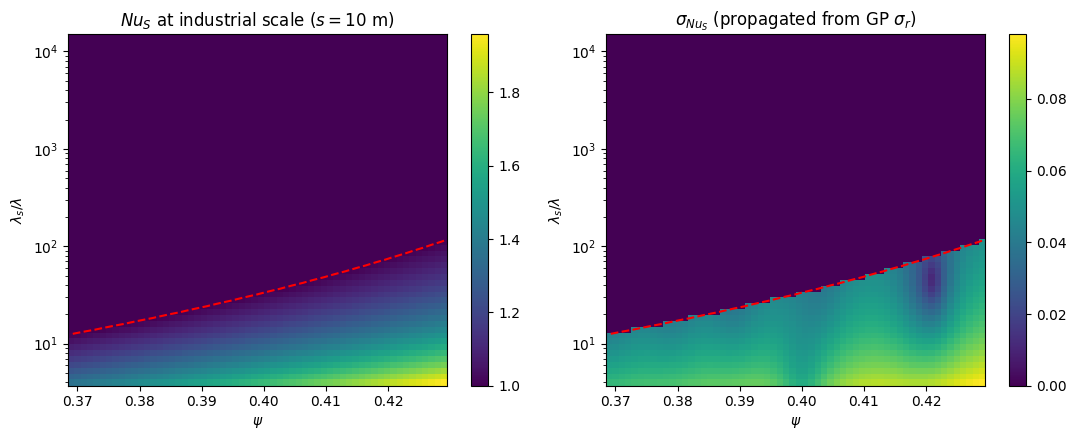

Ra*_S range at s=10 m: 6.33 - 151.46  (Ra*_crit = 39.48)
Fraction of grid above Ra*_crit (convecting): 26.6%
sigma_r range over grid: 0.0213 - 0.1011
sigma_Nu_S range over grid: 0.0000 - 0.0980
sigma_Nu_S at the grid point nearest (psi0, kappa0): 0.0115  (section 5 single-point value: 0.0111)


In [6]:
# --- sigma_Nu_S(psi, kappa) uncertainty map at industrial scale ---

# Predictive sigma_r over the (PSI, KAPPA) grid, holding other GP features at the representative row
rep_idx = len(df) // 2
X_grid = np.column_stack([
    np.log(np.array(KAPPA)).ravel(),
    np.array(PSI).ravel(),
    np.full(PSI.size, X_ml[rep_idx, 2]),  # d_over_D
    np.full(PSI.size, X_ml[rep_idx, 3]),  # log_Pe_feat
    np.full(PSI.size, X_ml[rep_idx, 4]),  # Nu_r
    np.full(PSI.size, X_ml[rep_idx, 5]),  # T_K
    np.full(PSI.size, X_ml[rep_idx, 6]),  # epsilon
])
Xs_grid = scaler.transform(X_grid)
_, sigma_r_grid = gp_uq.predict(Xs_grid, return_std=True)
SIGMA_R = sigma_r_grid.reshape(PSI.shape)

# Nu_S, lambda_Sch at industrial scale (s_ind) over the same (psi, kappa) grid
map_fn_ind = jax.vmap(jax.vmap(
    lambda p, k: nu_s_pipeline(p, k, d0, s_ind, lambda_f0, alpha_f0, T0),
    in_axes=(0, 0)), in_axes=(0, 0))
NU_S_IND, RA_STAR_IND, LAMBDA_SCH_IND = map_fn_ind(PSI, KAPPA)


def nu_s_of_lambda_sch_grid(lambda_sch, psi, s):
    alpha_eff = alpha_f0 * (lambda_sch / lambda_f0)
    nu_f = PR_N2 * alpha_f0
    K = permeability(psi, d0)
    beta = 1.0 / T0
    ra_star = rayleigh_darcy(beta, 50.0, s, K, nu_f, alpha_eff)
    return nusselt_porous(ra_star)


grad_fn = jax.vmap(jax.vmap(
    lambda l, p: jax.grad(nu_s_of_lambda_sch_grid, argnums=0)(l, p, s_ind),
    in_axes=(0, 0)), in_axes=(0, 0))
DNUS_DLAMBDASCH = grad_fn(LAMBDA_SCH_IND, PSI)

SIGMA_NUS = np.abs(np.array(DNUS_DLAMBDASCH)) * np.array(LAMBDA_SCH_IND) * SIGMA_R

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].pcolormesh(np.array(PSI), np.array(KAPPA), np.array(NU_S_IND), shading="auto")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\psi$"); axes[0].set_ylabel(r"$\lambda_s/\lambda$")
axes[0].set_title(rf"$Nu_S$ at industrial scale ($s={s_ind:.0f}$ m)")
axes[0].contour(np.array(PSI), np.array(KAPPA), np.array(RA_STAR_IND), levels=[float(RA_CRIT)], colors="r", linestyles="--")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(np.array(PSI), np.array(KAPPA), SIGMA_NUS, shading="auto")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\psi$"); axes[1].set_ylabel(r"$\lambda_s/\lambda$")
axes[1].set_title(r"$\sigma_{Nu_S}$ (propagated from GP $\sigma_r$)")
axes[1].contour(np.array(PSI), np.array(KAPPA), np.array(RA_STAR_IND), levels=[float(RA_CRIT)], colors="r", linestyles="--")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Ra*_S range at s={s_ind:.0f} m: {float(RA_STAR_IND.min()):.2f} - {float(RA_STAR_IND.max()):.2f}  (Ra*_crit = {float(RA_CRIT):.2f})")
print(f"Fraction of grid above Ra*_crit (convecting): {float(jnp.mean(RA_STAR_IND > RA_CRIT)) * 100:.1f}%")
print(f"sigma_r range over grid: {SIGMA_R.min():.4f} - {SIGMA_R.max():.4f}")
print(f"sigma_Nu_S range over grid: {SIGMA_NUS.min():.4f} - {SIGMA_NUS.max():.4f}")

# sanity check vs. the single-point result from section 5
i_psi = int(np.argmin(np.abs(np.array(psi_grid) - psi0)))
i_kappa = int(np.argmin(np.abs(np.array(kappa_grid) - kappa0)))
print(f"sigma_Nu_S at the grid point nearest (psi0, kappa0): {SIGMA_NUS[i_kappa, i_psi]:.4f}  "
      f"(section 5 single-point value: {sigma_NuS:.4f})")


**Finding**: at industrial scale (`s=10 m`), `26.6%` of the `(psi, kappa)` grid now exceeds `Ra*_crit` (vs. `0%` at lab scale) -- the convective branch occupies the upper-right of the map, with `Nu_S` ranging `1.0-1.96` across the grid. `sigma_r` itself varies by ~5x across the grid (`0.0213-0.1011`, vs. the single representative-point value of `0.0204` used in section 5), reflecting how the GP's calibrated uncertainty depends on `(psi, kappa)` through the other features held fixed.

The propagated `sigma_Nu_S` is **zero throughout the conduction-dominated region** (`Nu_S=1`, where `dNu_S/dlambda_Sch=0` by construction) and switches on exactly where convection switches on, reaching `0.098` at the grid's most strongly convecting corner -- i.e. **closure uncertainty only matters where convection is active**, and tracks the `Ra*_crit` contour rather than `sigma_r`'s own (smoother) variation. At the representative point, the grid-based estimate (`0.0115`) matches section 5's single-point value (`0.0111`) to within ~3%, confirming the two propagation routes are consistent.

**Bottom line**: this map makes the section-5 single-point propagation's implicit assumption explicit -- the `+/-1%` `Nu_S` uncertainty quoted there is representative only of *mildly* convecting conditions. Near the strongest industrial-scale convection in this swept range, the propagated uncertainty grows to `~5%` of `Nu_S` (`0.098/1.96`), still small in absolute terms but no longer negligible -- and it is concentrated entirely in the regime where the Fc correlation is active, leaving the (much larger, `74%` of the grid) conduction-dominated region with zero propagated uncertainty from this source.